In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from pathlib import Path
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TF version: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_DIR = Path('../data')
IMG_DIR = DATA_DIR / 'images'
PROC_DIR = Path('../data_processed')
CKPT_DIR = Path('../checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

# Hyperparameters
IMG_SIZE       = 224
EMBED_DIM      = 256       # Shared embedding dimensionality
TEXT_MAX_LEN   = 32        # Max caption tokens
VOCAB_SIZE     = 10000
BATCH_SIZE     = 64
EPOCHS         = 5
LR             = 1e-3
TEMPERATURE    = 0.07      # CLIP uses learned, but fixed works fine for a baseline

# Subsample to speed up first run (set to None to use the full dataset)
TRAIN_SUBSET = 20000
VAL_SUBSET   = 2000

In [3]:
train_df = pd.read_csv(PROC_DIR / 'train.csv')
val_df   = pd.read_csv(PROC_DIR / 'val.csv')
test_df  = pd.read_csv(PROC_DIR / 'test.csv')

if TRAIN_SUBSET:
    train_df = train_df.sample(TRAIN_SUBSET, random_state=42).reset_index(drop=True)
if VAL_SUBSET:
    val_df   = val_df.sample(VAL_SUBSET, random_state=42).reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 20,000 | Val: 2,000 | Test: 4,427


In [4]:
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=TEXT_MAX_LEN,
    standardize='lower_and_strip_punctuation',
)
vectorizer.adapt(train_df['caption'].values)

print('Vocab size:', len(vectorizer.get_vocabulary()))
print('Sample tokens:', vectorizer.get_vocabulary()[:30])

# Sanity check
sample = train_df['caption'].iloc[0]
print('\nCaption:', sample)
print('Tokens:', vectorizer([sample]).numpy()[0])

2026-04-30 14:05:37.229748: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-30 14:05:37.229779: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-30 14:05:37.229787: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2026-04-30 14:05:37.229832: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 14:05:37.229862: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 14:05:37.308658: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Vocab size: 6003
Sample tokens: ['', '[UNK]', 'in', 'a', 'for', 'wear', 'men', 'casual', 'women', 'summer', 'black', 'blue', 'white', 'fall', 'shoes', 'winter', 'tshirts', 'sports', 'brown', 'grey', 'tshirt', 'red', 'green', 'shirts', 'unisex', 'navy', 'formal', 'printed', 'pink', 'ethnic']

Caption: A men black tshirts, for casual wear in summer. United Colors of Benetton Men Printed Black Tshirt.
Tokens: [ 3  6 10 16  4  7  5  2  9 55 60 37 59  6 27 10 20  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0]


In [5]:
def load_image(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    # EfficientNet expects raw 0-255 inputs (its preprocessing is built in)
    return img

def make_dataset(df, training=False):
    paths    = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    captions = df['caption'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, captions))
    if training:
        ds = ds.shuffle(2048, reshuffle_each_iteration=True)
    ds = ds.map(
        lambda p, c: (load_image(p), c),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.map(
        lambda i, c: (i, vectorizer(c)),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)

# Smoke test one batch
for imgs, txt in train_ds.take(1):
    print('Image batch:', imgs.shape, imgs.dtype)
    print('Text batch: ', txt.shape, txt.dtype)

Image batch: (64, 224, 224, 3) <dtype: 'float32'>
Text batch:  (64, 32) <dtype: 'int64'>


In [6]:
def build_image_encoder(embed_dim=EMBED_DIM):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, pooling='avg', weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False  # freeze for first run

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.1)(x)
    out = layers.Dense(embed_dim)(x)
    return Model(inp, out, name='image_encoder')

image_encoder = build_image_encoder()
image_encoder.summary()

16705208/16705208 [==============================] - 1s 0us/step
Model: "image_encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 1280)              4049571   
 )                                                               
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
Total params: 4836771 (18.45 MB)
Trainable params: 787

In [7]:
class TransformerBlock(layers.Layer):
    def __init__(self, dim, heads=4, ff=256, dropout=0.1):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
        self.ffn  = tf.keras.Sequential([
            layers.Dense(ff, activation='relu'),
            layers.Dense(dim),
        ])
        self.ln1 = layers.LayerNormalization()
        self.ln2 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        a = self.attn(x, x, x)
        x = self.ln1(x + self.dropout(a, training=training))
        f = self.ffn(x)
        x = self.ln2(x + self.dropout(f, training=training))
        return x

def build_text_encoder(embed_dim=EMBED_DIM, dim=128):
    inp = layers.Input(shape=(TEXT_MAX_LEN,), dtype='int64')
    tok = layers.Embedding(VOCAB_SIZE, dim, mask_zero=True)(inp)
    pos = layers.Embedding(TEXT_MAX_LEN, dim)(tf.range(TEXT_MAX_LEN))
    x   = tok + pos
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(embed_dim)(x)
    return Model(inp, out, name='text_encoder')

text_encoder = build_text_encoder()
text_encoder.summary()

Model: "text_encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 32)]              0         
                                                                 
 embedding (Embedding)       (None, 32, 128)           1280000   
                                                                 
 tf.__operators__.add (TFOp  (None, 32, 128)           0         
 Lambda)                                                         
                                                                 
 transformer_block (Transfo  (None, 32, 128)           132480    
 rmerBlock)                                                      
                                                                 
 transformer_block_1 (Trans  (None, 32, 128)           132480    
 formerBlock)                                                    
                                                      

In [8]:
class DualEncoder(Model):
    def __init__(self, img_enc, txt_enc, temperature=TEMPERATURE):
        super().__init__()
        self.img_enc = img_enc
        self.txt_enc = txt_enc
        self.temperature = temperature
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs, training=False):
        imgs, txts = inputs
        ie = tf.math.l2_normalize(self.img_enc(imgs, training=training), axis=-1)
        te = tf.math.l2_normalize(self.txt_enc(txts, training=training), axis=-1)
        return ie, te

    def contrastive_loss(self, ie, te):
        logits = tf.matmul(ie, te, transpose_b=True) / self.temperature  # [B, B]
        labels = tf.range(tf.shape(logits)[0])
        loss_i = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        loss_t = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
        return tf.reduce_mean((loss_i + loss_t) / 2.0)

    def train_step(self, data):
        imgs, txts = data
        with tf.GradientTape() as tape:
            ie, te = self((imgs, txts), training=True)
            loss = self.contrastive_loss(ie, te)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

    def test_step(self, data):
        imgs, txts = data
        ie, te = self((imgs, txts), training=False)
        loss = self.contrastive_loss(ie, te)
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

model = DualEncoder(image_encoder, text_encoder)
model.compile(optimizer=tf.keras.optimizers.Adam(LR))

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/5


2026-04-30 14:05:43.642161: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


312/312 [==============================] - 83s 241ms/step - loss: 1.4874 - val_loss: 0.9885
Epoch 2/5
312/312 [==============================] - 75s 240ms/step - loss: 0.7546 - val_loss: 0.7472
Epoch 3/5
312/312 [==============================] - 75s 240ms/step - loss: 0.5844 - val_loss: 0.7058
Epoch 4/5
312/312 [==============================] - 77s 246ms/step - loss: 0.4873 - val_loss: 0.6469
Epoch 5/5
312/312 [==============================] - 74s 236ms/step - loss: 0.4168 - val_loss: 0.6624


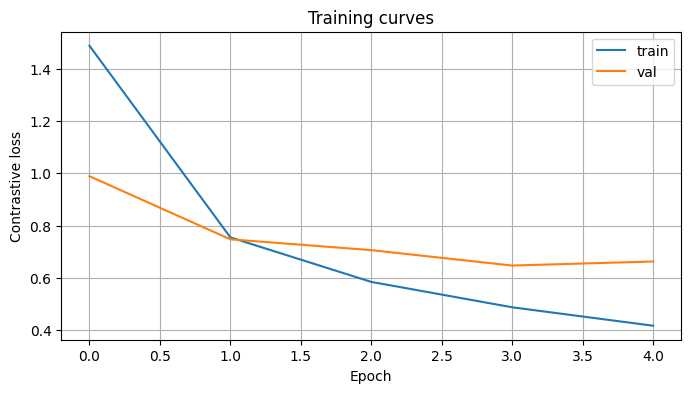

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Contrastive loss'); plt.legend(); plt.grid(True)
plt.title('Training curves')
plt.show()

In [11]:
def encode_dataset(df, batch_size=64):
    paths    = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    captions = df['caption'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, captions))
    ds = ds.map(lambda p, c: (load_image(p), c), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    img_emb, txt_emb = [], []
    for imgs, txts in ds:
        ie = tf.math.l2_normalize(image_encoder(imgs, training=False), axis=-1)
        te = tf.math.l2_normalize(text_encoder(vectorizer(txts), training=False), axis=-1)
        img_emb.append(ie.numpy())
        txt_emb.append(te.numpy())
    return np.concatenate(img_emb), np.concatenate(txt_emb)

img_emb, txt_emb = encode_dataset(val_df)
print('Image embeddings:', img_emb.shape)
print('Text embeddings: ', txt_emb.shape)

Image embeddings: (2000, 256)
Text embeddings:  (2000, 256)


In [12]:
def recall_at_k(query_emb, gallery_emb, ks=(1, 5, 10)):
    sims = query_emb @ gallery_emb.T  # [N, N]
    n = sims.shape[0]
    # rank: index ordering from highest to lowest similarity per query
    ranks = np.argsort(-sims, axis=1)
    correct = (ranks == np.arange(n)[:, None])
    return {f'R@{k}': correct[:, :k].any(axis=1).mean() for k in ks}

# Text query → image gallery
t2i = recall_at_k(txt_emb, img_emb)
# Image query → text gallery (sanity check)
i2t = recall_at_k(img_emb, txt_emb)

print('Text -> Image retrieval:', t2i)
print('Image -> Text retrieval:', i2t)

Text -> Image retrieval: {'R@1': 0.134, 'R@5': 0.416, 'R@10': 0.594}
Image -> Text retrieval: {'R@1': 0.138, 'R@5': 0.4015, 'R@10': 0.5895}


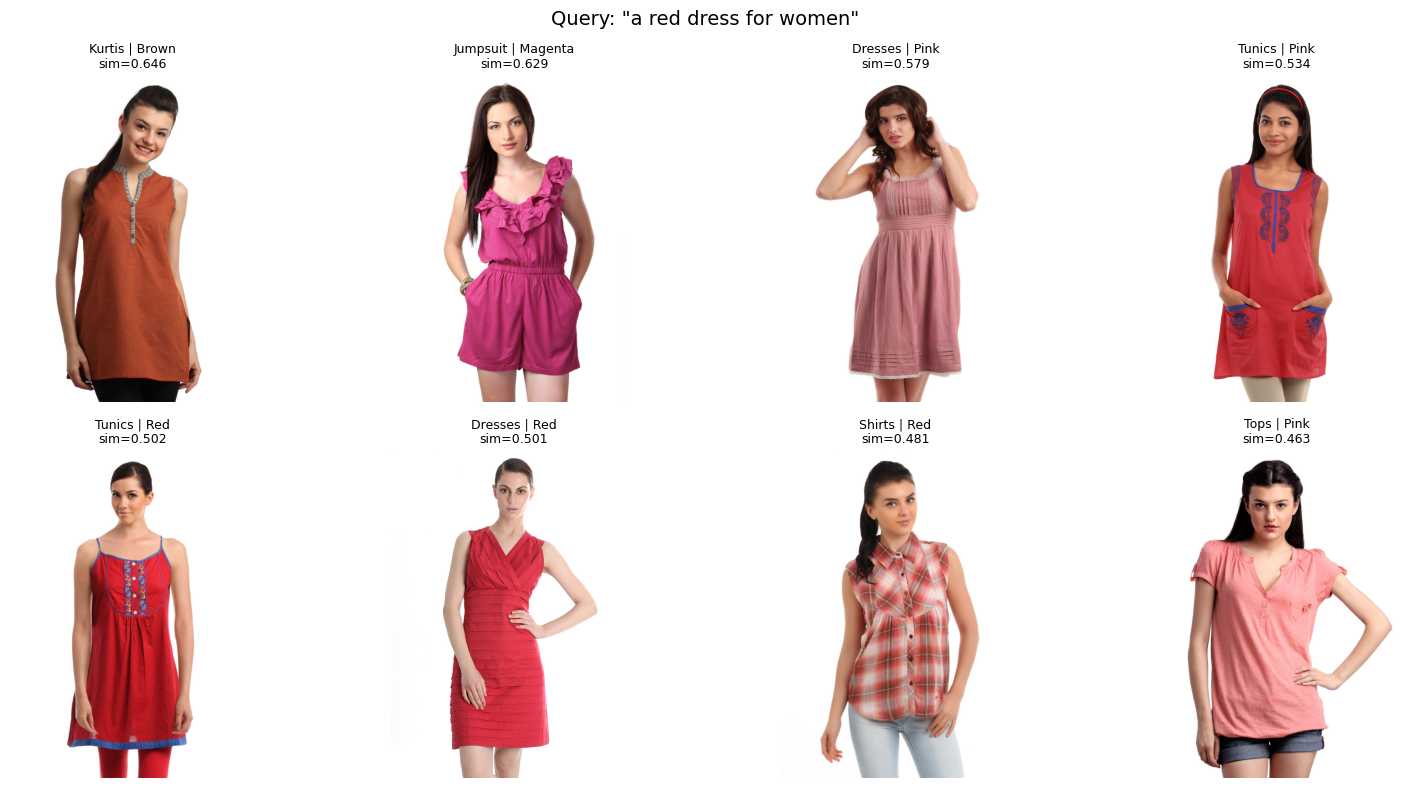

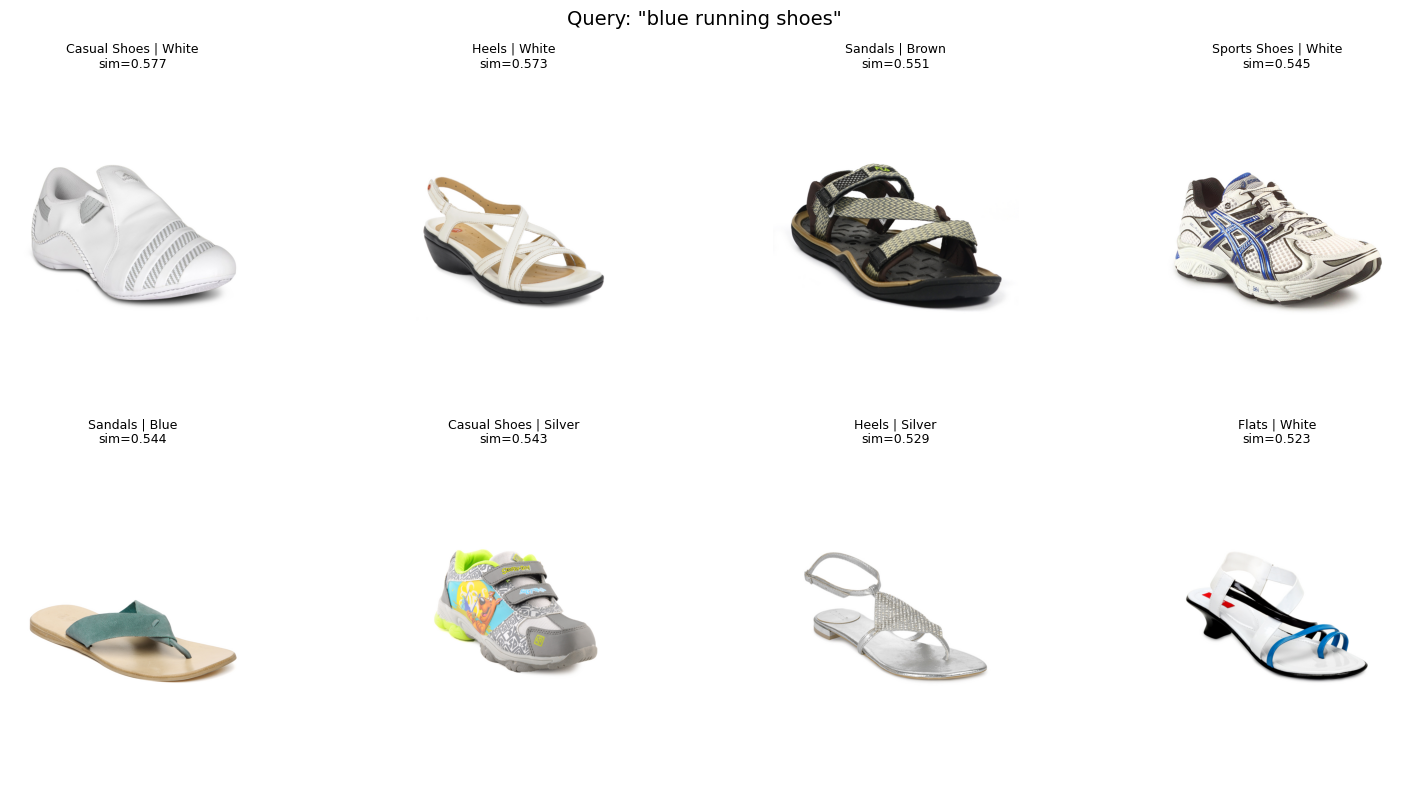

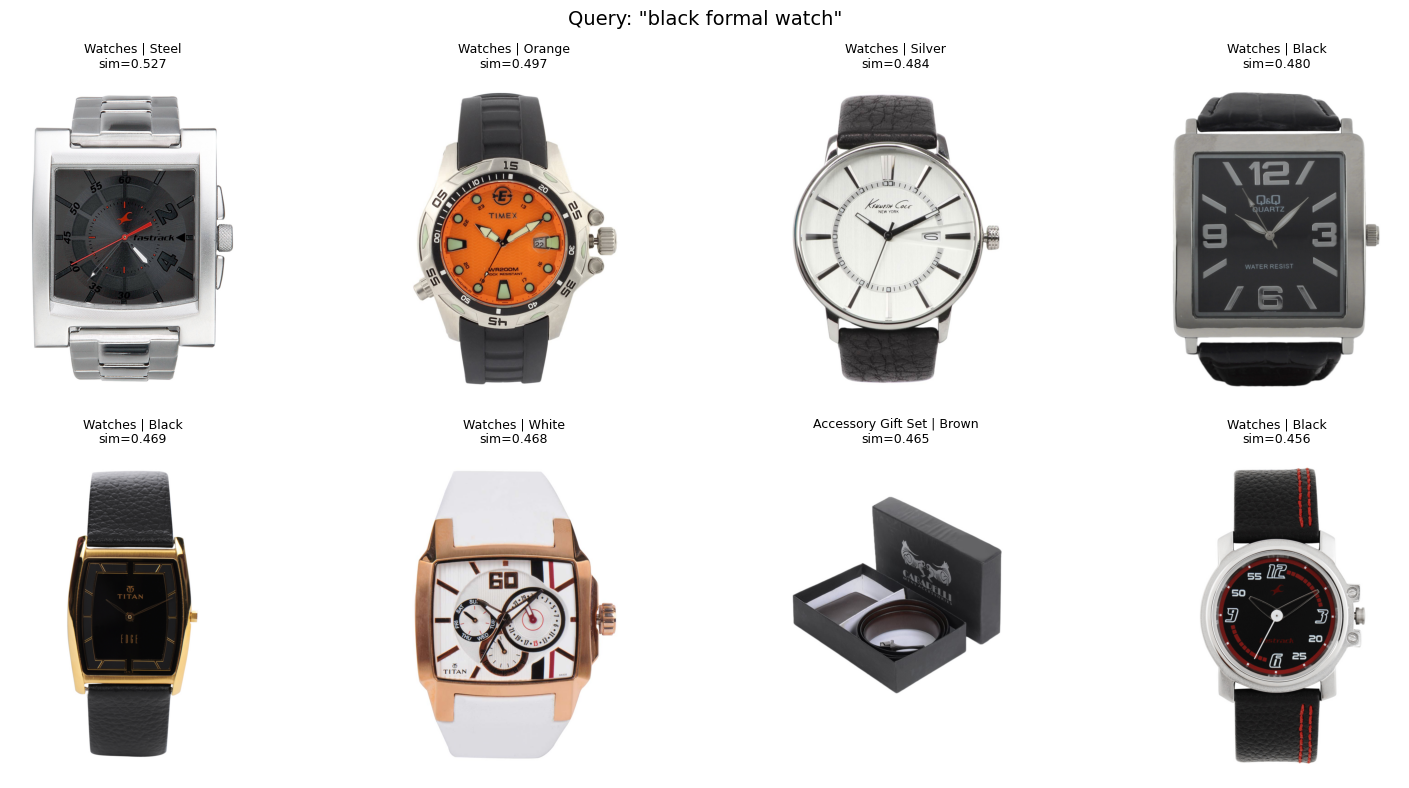

In [13]:
from PIL import Image

def search(query, df, gallery_emb, k=8):
    tokens = vectorizer([query])
    qe = tf.math.l2_normalize(text_encoder(tokens, training=False), axis=-1).numpy()
    sims = (qe @ gallery_emb.T).flatten()
    top = np.argsort(-sims)[:k]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, idx in zip(axes.flat, top):
        row = df.iloc[idx]
        img = Image.open(IMG_DIR / row['image_path'])
        ax.imshow(img)
        ax.set_title(f'{row["articleType"]} | {row["baseColour"]}\nsim={sims[idx]:.3f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Query: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

search('a red dress for women', val_df, img_emb)
search('blue running shoes', val_df, img_emb)
search('black formal watch', val_df, img_emb)

In [14]:
image_encoder.save_weights(CKPT_DIR / 'image_encoder.weights.h5')
text_encoder.save_weights(CKPT_DIR / 'text_encoder.weights.h5')

# Save vectorizer vocab too
import pickle
with open(CKPT_DIR / 'vectorizer_vocab.pkl', 'wb') as f:
    pickle.dump(vectorizer.get_vocabulary(), f)

print('Saved checkpoints to', CKPT_DIR.resolve())

Saved checkpoints to /Users/richy/Downloads/fashion-search/checkpoints
